In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
import xgboost as xgb
import joblib
from sklearn.ensemble import IsolationForest, RandomForestClassifier

In [23]:
df = pd.read_csv(r'C:\Users\magan\Downloads\HPE Project\Week 11\icmp_dataset_final.csv')

df.head()

,id,expiration_id,src_ip,src_mac,src_oui,src_port,dst_ip,dst_mac,dst_oui,dst_port,...,Fwd Pkts/s,Bwd Pkts/s,Down/Up Ratio,Pkt Len Var,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd IAT Tot,Bwd IAT Tot,Label,Unnamed: 0
0,28657,0,10.131.73.40,08:00:27:99:a4:3f,08:00:27,0,192.168.56.108,08:00:27:00:79:5d,08:00:27,0,...,0.277024,0.0,0,260.300000,94.4,0.0,18049,0,BENIGN,179484.0
1,628,0,10.184.240.220,08:00:27:99:a4:3f,08:00:27,0,192.168.56.109,08:00:27:00:79:5d,08:00:27,0,...,0.250188,0.0,0,651.333333,95.0,0.0,15988,0,BENIGN,151455.0
2,48976,0,10.38.27.158,08:00:27:41:90:3d,08:00:27,0,192.168.56.106,ff:ff:ff:ff:ff:ff,ff:ff:ff,0,...,0.149373,0.0,0,0.000000,32.0,0.0,40168,0,BENIGN,75069.0
3,7175,0,10.109.24.100,08:00:27:99:a4:3f,08:00:27,0,192.168.56.108,08:00:27:00:79:5d,08:00:27,0,...,0.281399,0.0,0,0.000000,32.0,0.0,10661,0,BENIGN,158002.0
4,731065,0,220.213.111.172,08:00:27:92:64:c5,08:00:27,0,192.168.100.20,08:00:27:30:32:e4,08:00:27,0,...,0.000000,0.0,0,0.000000,0.0,0.0,0,0,ICMP_FLOOD,NaN


In [24]:
df.shape

(488888, 118)

In [25]:
df.Label.value_counts()

Label
ICMP_FLOOD    268888
BENIGN        220000
Name: count, dtype: int64

In [26]:
for i in df.columns:
    print(i)

id
expiration_id
src_ip
src_mac
src_oui
src_port
dst_ip
dst_mac
dst_oui
dst_port
protocol
ip_version
vlan_id
tunnel_id
bidirectional_first_seen_ms
bidirectional_last_seen_ms
bidirectional_duration_ms
bidirectional_packets
bidirectional_bytes
src2dst_first_seen_ms
src2dst_last_seen_ms
src2dst_duration_ms
src2dst_packets
src2dst_bytes
dst2src_first_seen_ms
dst2src_last_seen_ms
dst2src_duration_ms
dst2src_packets
dst2src_bytes
bidirectional_min_ps
bidirectional_mean_ps
bidirectional_stddev_ps
bidirectional_max_ps
src2dst_min_ps
src2dst_mean_ps
src2dst_stddev_ps
src2dst_max_ps
dst2src_min_ps
dst2src_mean_ps
dst2src_stddev_ps
dst2src_max_ps
bidirectional_min_piat_ms
bidirectional_mean_piat_ms
bidirectional_stddev_piat_ms
bidirectional_max_piat_ms
src2dst_min_piat_ms
src2dst_mean_piat_ms
src2dst_stddev_piat_ms
src2dst_max_piat_ms
dst2src_min_piat_ms
dst2src_mean_piat_ms
dst2src_stddev_piat_ms
dst2src_max_piat_ms
SYN Flag Cnt
CWE Flag Count
ECE Flag Cnt
URG Flag Cnt
ACK Flag Cnt
PSH Flag Cnt


In [27]:
df['Unnamed: 0'].value_counts()

Unnamed: 0
179484.0    1
151455.0    1
75069.0     1
158002.0    1
55922.0     1
           ..
161785.0    1
57653.0     1
177836.0    1
161760.0    1
105960.0    1
Name: count, Length: 220000, dtype: int64

In [28]:
df.describe()

,id,expiration_id,src_port,dst_port,protocol,ip_version,vlan_id,tunnel_id,bidirectional_first_seen_ms,bidirectional_last_seen_ms,...,Flow Pkts/s,Fwd Pkts/s,Bwd Pkts/s,Down/Up Ratio,Pkt Len Var,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd IAT Tot,Bwd IAT Tot,Unnamed: 0
count,4.888880e+05,488888.0,488888.0,488888.0,488888.0,488888.0,488888.0,488888.0,4.888880e+05,4.888880e+05,...,488888.000000,488888.000000,488888.000000,488888.000000,488888.000000,488888.000000,488888.000000,4.888880e+05,4.888880e+05,220000.000000
mean,4.717404e+05,0.0,0.0,0.0,1.0,4.0,0.0,0.0,1.779509e+12,1.779509e+12,...,0.190921,0.190874,0.000047,0.000041,123.008347,391.824025,0.003373,1.047938e+04,3.478827e+00,112496.659527
std,8.009076e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.800120e+08,2.800235e+08,...,9.220151,9.220094,0.007522,0.006396,2321.770986,480.469064,0.860677,1.518391e+04,1.518748e+03,63822.464499
min,0.000000e+00,0.0,0.0,0.0,1.0,4.0,0.0,0.0,1.779257e+12,1.779257e+12,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,44.000000
25%,3.519900e+04,0.0,0.0,0.0,1.0,4.0,0.0,0.0,1.779257e+12,1.779257e+12,...,0.000000,0.000000,0.000000,0.000000,0.000000,40.500000,0.000000,0.000000e+00,0.000000e+00,57473.750000
50%,8.428100e+04,0.0,0.0,0.0,1.0,4.0,0.0,0.0,1.779258e+12,1.779258e+12,...,0.000000,0.000000,0.000000,0.000000,0.000000,93.400000,0.000000,0.000000e+00,0.000000e+00,112546.500000
75%,2.892238e+05,0.0,0.0,0.0,1.0,4.0,0.0,0.0,1.779807e+12,1.779807e+12,...,0.164763,0.164763,0.000000,0.000000,134.333333,841.000000,0.000000,1.930300e+04,0.000000e+00,167770.250000
max,3.022328e+06,0.0,0.0,0.0,1.0,4.0,0.0,0.0,1.779873e+12,1.779873e+12,...,4846.481853,4846.437377,1.298701,1.000000,720000.000000,1400.000000,548.000000,1.002385e+06,1.002385e+06,222869.000000


In [29]:
df.dtypes

id                    int64
expiration_id         int64
src_ip                  str
src_mac                 str
src_oui                 str
                     ...   
Bwd Seg Size Avg    float64
Fwd IAT Tot           int64
Bwd IAT Tot           int64
Label                   str
Unnamed: 0          float64
Length: 118, dtype: object

In [30]:
cols_to_drop = [
    "id", "expiration_id",
    "src_ip", "src_mac", "src_oui",
    "dst_ip", "dst_mac", "dst_oui","src_port","dst_port",
    "application_name", "application_category_name",
    "application_is_guessed", "application_confidence",
    "requested_server_name", "client_fingerprint",
    "server_fingerprint", "user_agent", "content_type",
    "vlan_id", "tunnel_id",
    "Unnamed: 0"
]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

In [31]:
df.shape

(488888, 96)

In [32]:
numeric = df.select_dtypes(include=[np.number])
print(f"Total numeric feature columns : {len(numeric.columns)}\n")
 
# ── 1. Entirely zero columns ──────────────────────────────────────────────────
all_zero = numeric.columns[(numeric == 0).all()].tolist()
print(f"1. All-zero columns ({len(all_zero)}):")
for c in all_zero:
    print(f"   {c}")
 
# ── 2. Zero variance (constant value, not necessarily zero) ───────────────────
zero_var = numeric.columns[numeric.std() == 0].tolist()
non_zero_constant = [c for c in zero_var if c not in all_zero]
print(f"\n2. Constant (non-zero) columns ({len(non_zero_constant)}):")
for c in non_zero_constant:
    print(f"   {c}  — constant value: {numeric[c].iloc[0]}")
 
# ── 3. Near-zero variance (std < 0.01) ───────────────────────────────────────
near_zero = numeric.columns[
    (numeric.std() > 0) & (numeric.std() < 0.01)
].tolist()
print(f"\n3. Near-zero variance columns — std < 0.01 ({len(near_zero)}):")
for c in near_zero:
    print(f"   {c}  std={numeric[c].std():.6f}  unique={numeric[c].nunique()}")
 
# ── 4. Columns that are >99% zero (sparse) ────────────────────────────────────
sparse = []
for c in numeric.columns:
    pct_zero = (numeric[c] == 0).mean()
    if pct_zero > 0.99 and c not in all_zero:
        sparse.append((c, pct_zero))
sparse.sort(key=lambda x: -x[1])
print(f"\n4. Sparse columns — >99% zero but not all-zero ({len(sparse)}):")
for c, pct in sparse:
    print(f"   {c}  {pct*100:.2f}% zeros")
 
# ── Summary ───────────────────────────────────────────────────────────────────
drop_candidates = list(set(all_zero + zero_var + [c for c, _ in sparse]))
print(f"\n── Summary ──────────────────────────────────────────────")
print(f"  All-zero columns          : {len(all_zero)}")
print(f"  Constant columns          : {len(zero_var)}")
print(f"  Near-zero variance        : {len(near_zero)}")
print(f"  Sparse >99% zero          : {len(sparse)}")
print(f"  Total drop candidates     : {len(drop_candidates)}")
print(f"  Remaining features        : {len(numeric.columns) - len(drop_candidates)}")
print(f"\nDrop list:\n{drop_candidates}")

Total numeric feature columns : 95

1. All-zero columns (24):
   SYN Flag Cnt
   CWE Flag Count
   ECE Flag Cnt
   URG Flag Cnt
   ACK Flag Cnt
   PSH Flag Cnt
   RST Flag Cnt
   FIN Flag Cnt
   src2dst_syn_packets
   src2dst_cwr_packets
   src2dst_ece_packets
   src2dst_urg_packets
   src2dst_ack_packets
   src2dst_psh_packets
   src2dst_rst_packets
   src2dst_fin_packets
   dst2src_syn_packets
   dst2src_cwr_packets
   dst2src_ece_packets
   dst2src_urg_packets
   dst2src_ack_packets
   dst2src_psh_packets
   dst2src_rst_packets
   dst2src_fin_packets

2. Constant (non-zero) columns (5):
   protocol  — constant value: 1
   ip_version  — constant value: 4
   udps.init_fwd_win  — constant value: -1
   udps.init_bwd_win  — constant value: -1
   udps.fwd_seg_size_min  — constant value: 28

3. Near-zero variance columns — std < 0.01 (3):
   udps.bwd_pkts_b_avg  std=0.007628  unique=2
   Bwd Pkts/s  std=0.007522  unique=20
   Down/Up Ratio  std=0.006396  unique=2

4. Sparse columns — >99% 

In [33]:
drop_cols = [
    "SYN Flag Cnt", "CWE Flag Count", "ECE Flag Cnt", "URG Flag Cnt",
    "ACK Flag Cnt", "PSH Flag Cnt", "RST Flag Cnt", "FIN Flag Cnt",
    "src2dst_syn_packets", "src2dst_cwr_packets", "src2dst_ece_packets",
    "src2dst_urg_packets", "src2dst_ack_packets", "src2dst_psh_packets",
    "src2dst_rst_packets", "src2dst_fin_packets",
    "dst2src_syn_packets", "dst2src_cwr_packets", "dst2src_ece_packets",
    "dst2src_urg_packets", "dst2src_ack_packets", "dst2src_psh_packets",
    "dst2src_rst_packets", "dst2src_fin_packets",
    "protocol", "ip_version",
    "udps.init_fwd_win", "udps.init_bwd_win", "udps.fwd_seg_size_min",
    
    # Backward direction — 100% zero, no replies captured in any flow ---> IMPORTANT necessary trade off to ensure that we can generate benign capture
    "dst2src_first_seen_ms", "dst2src_last_seen_ms", "dst2src_duration_ms",
    "dst2src_packets", "dst2src_bytes",
    "dst2src_min_ps", "dst2src_mean_ps", "dst2src_max_ps", "dst2src_stddev_ps",
    "dst2src_min_piat_ms", "dst2src_mean_piat_ms",
    "dst2src_stddev_piat_ms", "dst2src_max_piat_ms",
    "udps.bwd_header_len", "udps.bwd_byts_b_avg",
    "udps.bwd_pkts_b_avg", "udps.bwd_blk_rate_avg",
    "Bwd Pkts/s", "Bwd Seg Size Avg", "Bwd IAT Tot", "Down/Up Ratio","bidirectional_first_seen_ms",
    "bidirectional_last_seen_ms",   "src2dst_first_seen_ms", "src2dst_last_seen_ms",
    # Near-zero / sparse
    "udps.active_std",
]

df.drop(columns=drop_cols, inplace=True, errors="ignore")
print(f"Remaining features: {df.shape[1] - 1}")

Remaining features: 40


In [34]:
df.dtypes

bidirectional_duration_ms         int64
bidirectional_packets             int64
bidirectional_bytes               int64
src2dst_duration_ms               int64
src2dst_packets                   int64
src2dst_bytes                     int64
bidirectional_min_ps              int64
bidirectional_mean_ps           float64
bidirectional_stddev_ps         float64
bidirectional_max_ps              int64
src2dst_min_ps                    int64
src2dst_mean_ps                 float64
src2dst_stddev_ps               float64
src2dst_max_ps                    int64
bidirectional_min_piat_ms         int64
bidirectional_mean_piat_ms      float64
bidirectional_stddev_piat_ms    float64
bidirectional_max_piat_ms         int64
src2dst_min_piat_ms               int64
src2dst_mean_piat_ms            float64
src2dst_stddev_piat_ms          float64
src2dst_max_piat_ms               int64
udps.fwd_byts_b_avg             float64
udps.fwd_pkts_b_avg             float64
udps.fwd_blk_rate_avg           float64


In [35]:
X = df.drop(columns=["Label"])
le = LabelEncoder()
y = le.fit_transform(df["Label"])
print("Classes:", dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

Classes: {'BENIGN': np.int64(0), 'ICMP_FLOOD': np.int64(1)}
Train: 391,110  |  Test: 97,778


In [36]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

model = xgb.XGBClassifier(
    n_estimators     = 300,
    max_depth        = 6,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = scale,
    eval_metric      = "logloss",
    random_state     = 42,
    n_jobs           = -1,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)


[0]	validation_0-logloss:0.59958
[50]	validation_0-logloss:0.01473
[100]	validation_0-logloss:0.01193
[150]	validation_0-logloss:0.01194
[200]	validation_0-logloss:0.01197
[250]	validation_0-logloss:0.01198
[299]	validation_0-logloss:0.01198


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Optional[float]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[str], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load

In [37]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(f"\nAccuracy  : {accuracy_score(y_test, y_pred)*100:.4f}%")
print(f"Precision : {precision_score(y_test, y_pred)*100:.4f}%")
print(f"Recall    : {recall_score(y_test, y_pred)*100:.4f}%")
print(f"F1        : {f1_score(y_test, y_pred)*100:.4f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba):.6f}")

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix:")
print(f"               Pred BENIGN   Pred FLOOD")
print(f"Actual BENIGN  {tn:>11,}  {fp:>11,}")
print(f"Actual FLOOD   {fn:>11,}  {tp:>11,}")
print(f"\nFalse Positive Rate : {fp/(fp+tn)*100:.4f}%")
print(f"False Negative Rate : {fn/(fn+tp)*100:.4f}%")

print(classification_report(y_test, y_pred, target_names=le.classes_, digits=4))


Accuracy  : 99.5449%
Precision : 99.2156%
Recall    : 99.9628%
F1        : 99.5878%
ROC-AUC   : 0.999843

Confusion Matrix:
               Pred BENIGN   Pred FLOOD
Actual BENIGN       43,575          425
Actual FLOOD            20       53,758

False Positive Rate : 0.9659%
False Negative Rate : 0.0372%
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9903    0.9949     44000
  ICMP_FLOOD     0.9922    0.9996    0.9959     53778

    accuracy                         0.9954     97778
   macro avg     0.9958    0.9950    0.9954     97778
weighted avg     0.9955    0.9954    0.9954     97778



In [38]:
rf_model = RandomForestClassifier(
    n_estimators = 300,
    max_depth    = None,
    random_state = 42,
    n_jobs       = -1,
    class_weight = "balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("── Random Forest ────────────────────────────────────────")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_rf)*100:.4f}%")
print(f"Precision : {precision_score(y_test, y_pred_rf)*100:.4f}%")
print(f"Recall    : {recall_score(y_test, y_pred_rf)*100:.4f}%")
print(f"F1        : {f1_score(y_test, y_pred_rf)*100:.4f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_proba_rf):.6f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
print(f"\nConfusion Matrix:")
print(f"               Pred BENIGN   Pred FLOOD")
print(f"Actual BENIGN  {tn:>11,}  {fp:>11,}")
print(f"Actual FLOOD   {fn:>11,}  {tp:>11,}")
print(f"\nFalse Positive Rate : {fp/(fp+tn)*100:.4f}%")
print(f"False Negative Rate : {fn/(fn+tp)*100:.4f}%")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_, digits=4))

── Random Forest ────────────────────────────────────────
Accuracy  : 99.5449%
Precision : 99.2156%
Recall    : 99.9628%
F1        : 99.5878%
ROC-AUC   : 0.999843

Confusion Matrix:
               Pred BENIGN   Pred FLOOD
Actual BENIGN       43,575          425
Actual FLOOD            20       53,758

False Positive Rate : 0.9659%
False Negative Rate : 0.0372%
              precision    recall  f1-score   support

      BENIGN     0.9995    0.9903    0.9949     44000
  ICMP_FLOOD     0.9922    0.9996    0.9959     53778

    accuracy                         0.9954     97778
   macro avg     0.9958    0.9950    0.9954     97778
weighted avg     0.9955    0.9954    0.9954     97778



In [39]:
contamination = min((y_train == 1).sum() / len(y_train), 0.499)
print(f"\n── Isolation Forest (contamination={contamination:.3f}) ──────────────")

iso_model = IsolationForest(
    n_estimators  = 300,
    contamination = contamination,
    random_state  = 42,
    n_jobs        = -1,
)

iso_model.fit(X_train)
y_pred_iso_raw = iso_model.predict(X_test)
y_pred_iso     = np.where(y_pred_iso_raw == -1, 1, 0)
y_score_iso = -iso_model.decision_function(X_test)

print(f"Accuracy  : {accuracy_score(y_test, y_pred_iso)*100:.4f}%")
print(f"Precision : {precision_score(y_test, y_pred_iso)*100:.4f}%")
print(f"Recall    : {recall_score(y_test, y_pred_iso)*100:.4f}%")
print(f"F1        : {f1_score(y_test, y_pred_iso)*100:.4f}%")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_score_iso):.6f}")

cm_iso = confusion_matrix(y_test, y_pred_iso)
tn, fp, fn, tp = cm_iso.ravel()
print(f"\nConfusion Matrix:")
print(f"               Pred BENIGN   Pred FLOOD")
print(f"Actual BENIGN  {tn:>11,}  {fp:>11,}")
print(f"Actual FLOOD   {fn:>11,}  {tp:>11,}")
print(f"\nFalse Positive Rate : {fp/(fp+tn)*100:.4f}%")
print(f"False Negative Rate : {fn/(fn+tp)*100:.4f}%")
print(classification_report(y_test, y_pred_iso, target_names=le.classes_, digits=4))


── Isolation Forest (contamination=0.499) ──────────────
Accuracy  : 17.1388%
Precision : 22.0434%
Recall    : 19.9710%
F1        : 20.9561%
ROC-AUC   : 0.091144

Confusion Matrix:
               Pred BENIGN   Pred FLOOD
Actual BENIGN        6,018       37,982
Actual FLOOD        43,038       10,740

False Positive Rate : 86.3227%
False Negative Rate : 80.0290%
              precision    recall  f1-score   support

      BENIGN     0.1227    0.1368    0.1293     44000
  ICMP_FLOOD     0.2204    0.1997    0.2096     53778

    accuracy                         0.1714     97778
   macro avg     0.1716    0.1682    0.1695     97778
weighted avg     0.1764    0.1714    0.1735     97778



1    0.549999
0    0.450001
Name: proportion, dtype: float64


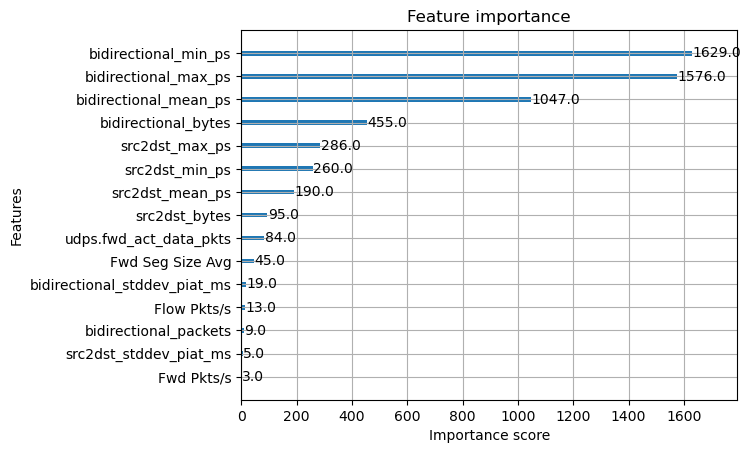

In [40]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Check if dataset was balanced
print(pd.Series(y).value_counts(normalize=True))

# See what the model actually learned
plot_importance(model, max_num_features=15)
plt.show()

In [46]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, 'feature_columns2.pkl')
joblib.dump(le, 'label_encoder2.pkl')
joblib.dump(model, 'xgboost_model2.pkl')

['xgboost_model2.pkl']